## DSAN 6000 Homework 5: "Freezing" Python Computations with Polars

> **Note**: If you run into RAM overflow issues at any point in the assignment (which will be indicated by, e.g., the kernel or the Python process being killed), you can switch from using `s3://dsan6000-data/acled_events.parquet` as the main data file to `s3://dsan6000-data/acled_civilian_events.parquet` instead.
> 
> The latter file is about 6x smaller (since it only includes events in the ACLED database which involve civilian targets), and should prevent any RAM overflows. But, you should first try the assignment with the full `acled_events.parquet` file, to see the full extent of the memory savings!

## Overview

This assignment picks up right where you left off in HW4, where you gained some hands-on experience with the `.parquet` format: how it stores important metadata information in its file footer, and how it achieves compression by using the Run-Length Encoding (RLE) scheme to condense repeated data values.

Specifically, towards the end of the last assignment (Question 2.2 and Question 3), you may have noticed two things:

* (a) In **Question 2.2**, we had to employ an entirely new language – DuckDB's implementation of SQL – to carry out our data analysis, despite the fact that we were working with Python code in a `.py` file. Essentially, we used Python's triple-quoting feature to "smuggle in" code from an entirely separate language, by including that code between a starting and ending `"""`.
* (b) From this same perspective, **Question 3** may have felt even more bizarre: not only were we employing the same importing-non-Python-code-into-Python trick as in Q2.2, but this time we were also using it to query a **Python object**, the Pandas `DataFrame` that had been created in a previous code cell.

If you love SQL, and if you find yourself more easily thinking through data-analysis tasks via its **declarative** format, you can carry on using this hybrid SQL-queries-within-Python approach after this assignment (for example, in your **Final Project**❗️).

But, if you were disturbed by this mixing-and-matching of languages, **Polars** is here in HW5 to help you sleep a bit better! Because, as promised in the intro email sent out before the course even started, in this assignment you will learn how to take the [**eagerly**-evaluated] Pandas workflows you are already familiar with and "translate" them into **lazily**-evaluated Python code (as opposed to SQL code that you shove into Python via `"""`).

After a refresher/slightly-deeper-dive into the Parquet format in Part 1, the remaining parts will have you resuscitate your Pandas code from HW4 Q2.1 and then walk you through "translating" it into Polars code. But before you start, here and elsewhere, please keep the **core difference** between the two approaches in the front of your mind:

> ***Pandas*** allows you to instantly see the effects (e.g., in the output of a code cell) of applying a "piece" of computation to a "piece" of data, due to its **eager evaluation** approach
> 
> ***Polars***, on the other hand, **separates computation from data**, allowing its underlying (Rust-based) **query optimizer** to **plan out in advance** the best way to carry out a given computation on a given dataset, before actually running it.

Finally, linking this assignment back to HW4 once more, note how your writing of DuckDB queries as Python strings *implicitly* achieved this separation of computation from data: you had to write a query from start to finish, as a self-contained unit, *before* asking the DuckDB engine (via `con.execute()`) to *apply it* to a particular piece of data. This is how you were then able to easily "move" this unit of computation from the `.py` file in Q2.2 querying an external S3 object to the `.ipynb` file in Q3 querying an in-memory `DataFrame`!

## Part 1: A Deeper Dive Into Parquet's RLE Compression and Row-Grouping

In HW4 Q1, you opened up the "black box" of the `.parquet` format, explicitly looking into the metadata stored in its footer and its compression of the data within each column (with varying degrees of "success" in terms of its ability to compress different formats).

This question, partly as a refresher and partly as a deeper-dive, will first test your understanding of RLE Compression and then move onto the additional "dimension" available to Parquet for compression: the partition of a full dataset into separate `.parquet`-encoded row groups based on some important index of the rows (typically a **date**).

### Question 1.1: What Makes Columns More vs. Less Compressible?

The following code cell constructs a large-$N$ `DataFrame` with multiple columns, each of which has a particular **distribution** of data values making it more or less amenable to Parquet's specific compression techniques:

In [15]:
#| label: Q1.1-init
import pandas as pd
import numpy as np
rng = np.random.default_rng(seed=6000)
N = 1_000_000

demo_df = pd.DataFrame({'id': range(N)})

# Most compressible: all values are identical
demo_df['is_data'] = True

# Very compressible: column contains *runs* of consecutive identical values
demo_df['rank'] = 'A'
demo_df.iloc[250_000:500_000, -1] = 'B'
demo_df.iloc[500_000:750_000, -1] = 'C'
demo_df.iloc[750_000:N, -1] = 'D'

# Less compressible: four unique values, but, spread randomly across df
demo_df['category'] = rng.permuted(demo_df['rank'])

# Least compressible: random values
demo_df['rand_val'] = rng.random(size=N)

demo_df

,id,is_data,rank,category,rand_val
0,0,True,A,A,0.945182
1,1,True,A,D,0.683398
2,2,True,A,C,0.763598
3,3,True,A,A,0.661641
4,4,True,A,C,0.365353
...,...,...,...,...,...
999995,999995,True,D,B,0.107236
999996,999996,True,D,B,0.968375
999997,999997,True,D,B,0.642580
999998,999998,True,D,C,0.337793


In [33]:
mem_df = (demo_df.memory_usage(index=False) / (1024 ** 2)).to_frame().reset_index()
mem_df.columns = ['col_name','memory_mb']
mem_df


,col_name,memory_mb
0,id,7.629395
1,is_data,0.953674
2,rank,8.583069
3,category,8.583069
4,rand_val,7.629395


In [34]:
demo_df.to_parquet('demo.parquet')

In [35]:
import duckdb

con = duckdb.connect()
pmeta_query = """
SELECT * FROM parquet_metadata('demo.parquet')
"""
pmeta_df = con.execute(pmeta_query).df()
with pd.option_context('display.max_columns', None):
  display(pmeta_df)

,file_name,row_group_id,row_group_num_rows,row_group_num_columns,row_group_bytes,column_id,file_offset,num_values,path_in_schema,type,stats_min,stats_max,stats_null_count,stats_distinct_count,stats_min_value,stats_max_value,compression,encodings,index_page_offset,dictionary_page_offset,data_page_offset,total_compressed_size,total_uncompressed_size,key_value_metadata,bloom_filter_offset,bloom_filter_length,min_is_exact,max_is_exact,row_group_compressed_bytes,geo_bbox,geo_types
0,demo.parquet,0,1000000,5,16932857,0,0,1000000,id,INT64,0,999999,0,<NA>,0,999999,SNAPPY,"PLAIN, RLE, RLE_DICTIONARY",<NA>,4,525342,4276971,8274562,{},<NA>,<NA>,True,True,12817391,<NA>,<NA>
1,demo.parquet,0,1000000,5,16932857,1,0,1000000,is_data,BOOLEAN,true,true,0,<NA>,true,true,SNAPPY,"RLE, PLAIN",<NA>,<NA>,4276975,8500,127350,{},<NA>,<NA>,True,True,12817391,<NA>,<NA>
2,demo.parquet,0,1000000,5,16932857,2,0,1000000,rank,BYTE_ARRAY,NaN,NaN,0,<NA>,A,D,SNAPPY,"PLAIN, RLE, RLE_DICTIONARY",<NA>,4285475,4285511,2344,2242,{},<NA>,<NA>,True,True,12817391,<NA>,<NA>
3,demo.parquet,0,1000000,5,16932857,3,0,1000000,category,BYTE_ARRAY,NaN,NaN,0,<NA>,A,D,SNAPPY,"PLAIN, RLE, RLE_DICTIONARY",<NA>,4287819,4287855,254392,254140,{},<NA>,<NA>,True,True,12817391,<NA>,<NA>
4,demo.parquet,0,1000000,5,16932857,4,0,1000000,rand_val,DOUBLE,9.001978885647688e-07,0.99999993554024,0,<NA>,9.001978885647688e-07,0.99999993554024,SNAPPY,"PLAIN, RLE, RLE_DICTIONARY",<NA>,4542211,5592399,8275184,8274563,{},<NA>,<NA>,True,True,12817391,<NA>,<NA>


In [38]:
comp_df = pmeta_df[['path_in_schema','total_compressed_size']].copy()
comp_df['total_compressed_size'] = comp_df['total_compressed_size'] / (1024 ** 2)
comp_df = comp_df.rename(columns={
  'path_in_schema': 'col_name',
  'total_compressed_size': 'comp_memory_mb',
})
comp_df = comp_df.merge(mem_df, on='col_name')
comp_df['comp_ratio'] = comp_df['memory_mb'] / comp_df['comp_memory_mb']
comp_df

,col_name,comp_memory_mb,memory_mb,comp_ratio
0,id,4.078837,7.629395,1.870483
1,is_data,0.008106,0.953674,117.647059
2,rank,0.002235,8.583069,3839.590444
3,category,0.242607,8.583069,35.378471
4,rand_val,7.891830,7.629395,0.966746


Here, take a minute to reflect on these findings before moving to the next question! You don't need to respond to these explicitly, just think about them in your head – they're written out here just to... force you to see them while you scroll to the next part 😜

**Did the *ordering* of columns, from most to least compressible, match your expectations?**

**Did the *magnitude* of the compression ratios match your expectations?**

For example, did you expect that the difference in compression ratios between the *sorted* `rank` column and the *unsorted* `category` column would be so large? (Admittedly, I didn't think they'd be so large, when I was making the assignment!)

**How might these ratios *scale* for larger and larger datasets?**

Here, the tricky aspect we'll address right away in the next part is that, when the data files get *too* large you may want to **split** them into multiple pieces – for example, in class we've discussed a few times how files relating to North America might be kept on servers in North America, while files relating to Europe might be kept on servers in the EU, especially given the stricter GDPR **data privacy regulations** operating in the EU.

The difficulty comes from the fact that, sadly, any naïve "chopping" of a given `.parquet` file at some random point might ruin the entire compression scheme! For example, if you have an RLE-encoded column like the `is_data` column here, and you decide to "chop" the `demo.parquet` file at row 800,000 (to move the last 200,000 rows into a separate file called `demo_2.parquet`), you would (at minimum) need to write updated metadata into the new file reflecting that it now only has 200,000 consecutive identical values.

It gets worse, however, since (as you saw when displaying the Parquet metadata in HW4) Parquet keeps track of more in-depth statistics, such as the minimum and maximum values within a given column, all of which would need to be recomputed to carry out such a "chopping" without destroying the benefits of the Parquet format.

Thus, in the next question, you'll see how the Parquet schema **also provides functionality to carry out this of "chopping" as efficiently as possible**, by leveraging explicitly-marked **row groups** as partition keys.

### Question 1.2: Partitioning a `.parquet` File Into Row Groups

## Part 2: Translating From Pandas to Polars

Now that you know how to take advantage of Hive partitioning when creating and analyzing data in `.parquet` format, let's put that knowledge to work, using Polars to analyze a Hive-partitined dataset as efficiently as possible!

Specifically, we will carry out some data analysis tasks that will feel familiar to you from the prior practice you've had with Pandas `DataFrame`s. The new element here will be carrying out these workflows using `LazyFrame`s as lazily-evaluated substitutes for `DataFrame`s, and your job will be to become more and more comfortable with this approach.

The scary part will be that, as mentioned in class, **`LazyFrame`s don't actually contain any data in themselves!** They contain **"blueprints"** for the creation of `DataFrame`s from input data, based on chained-together **expressions** which "explain" to Polars the operations you're hoping to carry out on the data.



### Question 2.1: 

In [4]:
#| label: Q2.1-response

import polars as pl
acled_lf = pl.scan_parquet(
  's3://dsan6000-data/acled_events.parquet',
  storage_options={
    "aws_region": "us-east-1",
    "aws_skip_signature": "true",
  },
)
acled_lf.collect_schema()

Schema([('event_id_cnty', String),
        ('event_date', String),
        ('year', Int64),
        ('time_precision', Int64),
        ('disorder_type', String),
        ('event_type', String),
        ('sub_event_type', String),
        ('actor1', String),
        ('assoc_actor_1', String),
        ('inter1', String),
        ('actor2', String),
        ('assoc_actor_2', String),
        ('inter2', String),
        ('interaction', String),
        ('civilian_targeting', String),
        ('iso', Int64),
        ('region', String),
        ('country', String),
        ('admin1', String),
        ('admin2', String),
        ('admin3', String),
        ('location', String),
        ('latitude', Float64),
        ('longitude', Float64),
        ('geo_precision', Int64),
        ('source', String),
        ('source_scale', String),
        ('notes', String),
        ('fatalities', Int64),
        ('tags', String),
        ('timestamp', Int64)])

In [5]:
acled_lf.head(5).collect()

event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,actor2,assoc_actor_2,inter2,interaction,civilian_targeting,iso,region,country,admin1,admin2,admin3,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp
str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,f64,f64,i64,str,str,str,i64,str,i64
"""RWA3""","""1997-01-01""",1997,1,"""Political violence""","""Battles""","""Armed clash""","""Military Forces of Rwanda (199…",null,"""State forces""","""Hutu Rebels""",null,"""Rebel group""","""State forces-Rebel group""",null,646,"""Eastern Africa""","""Rwanda""","""West""","""Nyamasheke""","""Shangi""","""Gafunzo""",-2.3927,29.0044,1,"""Local Source""","""International""","""Security forces kill a rebel o…",1,null,1618568810
"""ALG1""","""1997-01-01""",1997,1,"""Political violence""","""Violence against civilians""","""Attack""","""GIA: Armed Islamic Group""",null,"""Rebel group""","""Civilians (Algeria)""",null,"""Civilians""","""Rebel group-Civilians""","""Civilian targeting""",12,"""Northern Africa""","""Algeria""","""Tipaza""","""Douaouda""",null,"""Douaouda""",36.6725,2.7894,1,"""Algeria Watch""","""Other""","""5 January: Beheading of 5 citi…",5,null,1582579226
"""SIE1""","""1997-01-01""",1997,3,"""Strategic developments""","""Strategic developments""","""Looting/property destruction""","""RUF: Revolutionary United Fron…",null,"""Rebel group""","""Civilians (Sierra Leone)""",null,"""Civilians""","""Rebel group-Civilians""",null,694,"""Western Africa""","""Sierra Leone""","""Northern""","""Tonkolili""","""Kholifa Rowalla""","""Magburaka""",8.7167,-11.95,3,"""SL-LED; No Peace Without Justi…","""Local partner-New media""","""Looting""",0,null,1607978719
"""SIE4""","""1997-01-01""",1997,3,"""Strategic developments""","""Strategic developments""","""Looting/property destruction""","""Kamajor Militia""",null,"""Political militia""","""Civilians (Sierra Leone)""",null,"""Civilians""","""Political militia-Civilians""",null,694,"""Western Africa""","""Sierra Leone""","""Southern""","""Bonthe""","""Nongoba Bullom""","""Badjia""",7.4338,-12.2419,2,"""No Peace Without Justice; SL-L…","""Local partner-New media""","""Looting""",0,null,1607978767
"""SIE5""","""1997-01-01""",1997,3,"""Strategic developments""","""Strategic developments""","""Looting/property destruction""","""Kamajor Militia""",null,"""Political militia""","""Civilians (Sierra Leone)""",null,"""Civilians""","""Political militia-Civilians""",null,694,"""Western Africa""","""Sierra Leone""","""Southern""","""Bo""","""Valunia""","""Valunia""",8.3172,-11.7336,2,"""No Peace Without Justice; SL-L…","""Local partner-New media""","""Looting""",0,null,1607978771


In [7]:
lbn_expr = pl.col("country") == "Lebanon"
print(type(lbn_expr))
print(lbn_expr)

<class 'polars.expr.expr.Expr'>
[(col("country")) == ("Lebanon")]


In [9]:
acled_lf.filter(lbn_expr).head(5).collect()

event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,actor2,assoc_actor_2,inter2,interaction,civilian_targeting,iso,region,country,admin1,admin2,admin3,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp
str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,f64,f64,i64,str,str,str,i64,str,i64
"""LBN6985""","""2016-01-01""",2016,1,"""Political violence""","""Explosions/Remote violence""","""Grenade""","""Unidentified Armed Group (Leba…",null,"""Political militia""",null,null,null,"""Political militia only""",null,422,"""Middle East""","""Lebanon""","""Akkar""","""Akkar""",null,"""Wadi Khaled""",34.6194,36.3736,2,"""Lebanon Support; El Nashra""","""Local partner-Other""","""On 1 January 2016, a grenade w…",0,null,1603128565
"""LBN449""","""2016-01-01""",2016,1,"""Political violence""","""Explosions/Remote violence""","""Shelling/artillery/missile att…","""Military Forces of Israel (200…",null,"""External/Other forces""",null,null,null,"""External/Other forces only""",null,422,"""Middle East""","""Lebanon""","""Al Nabatieh""","""Hasbeiya""",null,"""Chebaa""",33.3475,35.7492,2,"""Times of Israel""","""Regional""","""Israeli forces shelled the Leb…",0,null,1756770056
"""LBN451""","""2016-01-02""",2016,1,"""Strategic developments""","""Strategic developments""","""Disrupted weapons use""","""Military Forces of Lebanon (20…",null,"""State forces""","""Unidentified Armed Group (Leba…",null,"""Political militia""","""State forces-Political militia""",null,422,"""Middle East""","""Lebanon""","""North""","""Tripoli""",null,"""Tripoli""",34.4367,35.8497,1,"""National News Agency Lebanon""","""National""","""Defusal: State security patrol…",0,null,1780358448
"""LBN450""","""2016-01-02""",2016,1,"""Political violence""","""Explosions/Remote violence""","""Shelling/artillery/missile att…","""Military Forces of Israel (200…",null,"""External/Other forces""",null,null,null,"""External/Other forces only""",null,422,"""Middle East""","""Lebanon""","""Al Nabatieh""","""Hasbeiya""",null,"""Chebaa""",33.3475,35.7492,2,"""Times of Israel""","""Regional""","""Israeli forces shelled the Leb…",0,null,1756770056
"""LBN10346""","""2016-01-03""",2016,1,"""Demonstrations""","""Protests""","""Peaceful protest""","""Protesters (Lebanon)""","""Shiite Muslim Group (Lebanon)""","""Protesters""",null,null,null,"""Protesters only""",null,422,"""Middle East""","""Lebanon""","""Beirut""","""Beirut""",null,"""Beirut - Port""",33.8982,35.5074,1,"""El Nashra""","""National""","""On 3 January 2016, a solidarit…",0,null,1620069519


In [13]:
acled_lf.filter(lbn_expr).group_by('year').len().sort('year').collect()

year,len
i64,u32
2016,924
2017,756
2018,577
2019,3598
2020,2992
2021,3214
2022,1303
2023,3191
2024,14698


In [14]:
acled_lf.group_by('year').len().sort('year').collect()

year,len
i64,u32
1997,3141
1998,4421
1999,4758
2000,4116
2001,3557
…,…
2021,295173
2022,324774
2023,355116


### Question 2.2: Caching Intermediate Results in RAM

Now that you've identified that the *subset* of records relating to Lebanon *does* fit inside RAM, we have "unlocked" a new stage in the data analysis! Although Polars does optimize the loading from S3 as much as possible, every Polars expression we have materialized (by calling `collect()`) thus far has re-read the data from scratch, from the remote S3 bucket into your EC2 instance's RAM.

However, we may have decided by now that we'd like to analyze just the Lebanon events. Since these events do fit in RAM, we can move to a new stage where:

* We **materialize** the Lebanon events from the remote S3 bucket into the local RAM, but
* We then **still want to optimize** our queries on this locally-materialized data

To achieve both of these goals, we write some code that would seem strange if you didn't know that these were the goals:

In [17]:
lbn_df = acled_lf.filter(lbn_expr).collect()
lbn_df.head()

event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,actor2,assoc_actor_2,inter2,interaction,civilian_targeting,iso,region,country,admin1,admin2,admin3,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp
str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,f64,f64,i64,str,str,str,i64,str,i64
"""LBN6985""","""2016-01-01""",2016,1,"""Political violence""","""Explosions/Remote violence""","""Grenade""","""Unidentified Armed Group (Leba…",null,"""Political militia""",null,null,null,"""Political militia only""",null,422,"""Middle East""","""Lebanon""","""Akkar""","""Akkar""",null,"""Wadi Khaled""",34.6194,36.3736,2,"""Lebanon Support; El Nashra""","""Local partner-Other""","""On 1 January 2016, a grenade w…",0,null,1603128565
"""LBN449""","""2016-01-01""",2016,1,"""Political violence""","""Explosions/Remote violence""","""Shelling/artillery/missile att…","""Military Forces of Israel (200…",null,"""External/Other forces""",null,null,null,"""External/Other forces only""",null,422,"""Middle East""","""Lebanon""","""Al Nabatieh""","""Hasbeiya""",null,"""Chebaa""",33.3475,35.7492,2,"""Times of Israel""","""Regional""","""Israeli forces shelled the Leb…",0,null,1756770056
"""LBN451""","""2016-01-02""",2016,1,"""Strategic developments""","""Strategic developments""","""Disrupted weapons use""","""Military Forces of Lebanon (20…",null,"""State forces""","""Unidentified Armed Group (Leba…",null,"""Political militia""","""State forces-Political militia""",null,422,"""Middle East""","""Lebanon""","""North""","""Tripoli""",null,"""Tripoli""",34.4367,35.8497,1,"""National News Agency Lebanon""","""National""","""Defusal: State security patrol…",0,null,1780358448
"""LBN450""","""2016-01-02""",2016,1,"""Political violence""","""Explosions/Remote violence""","""Shelling/artillery/missile att…","""Military Forces of Israel (200…",null,"""External/Other forces""",null,null,null,"""External/Other forces only""",null,422,"""Middle East""","""Lebanon""","""Al Nabatieh""","""Hasbeiya""",null,"""Chebaa""",33.3475,35.7492,2,"""Times of Israel""","""Regional""","""Israeli forces shelled the Leb…",0,null,1756770056
"""LBN10346""","""2016-01-03""",2016,1,"""Demonstrations""","""Protests""","""Peaceful protest""","""Protesters (Lebanon)""","""Shiite Muslim Group (Lebanon)""","""Protesters""",null,null,null,"""Protesters only""",null,422,"""Middle East""","""Lebanon""","""Beirut""","""Beirut""",null,"""Beirut - Port""",33.8982,35.5074,1,"""El Nashra""","""National""","""On 3 January 2016, a solidarit…",0,null,1620069519


In [21]:
lbn_df.write_parquet(
  'lbn_data',
  partition_by='year',
)

In [18]:
type(lbn_df)

polars.dataframe.frame.DataFrame

In [22]:
lbn_lf = lbn_df.lazy()

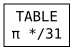

In [ ]:
# Reminder: IR = "Intermediate Representation"
lbn_lf.show_graph(plan_stage="ir")

In [27]:
fatal_expr = pl.col('fatalities') > 0

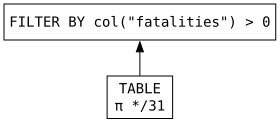

In [28]:
lbn_fat_lf = lbn_lf.filter(fatal_expr)
lbn_fat_lf.show_graph(plan_stage='ir')

In [29]:
lbn_fat_lf.collect()

event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,actor2,assoc_actor_2,inter2,interaction,civilian_targeting,iso,region,country,admin1,admin2,admin3,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp
str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,f64,f64,i64,str,str,str,i64,str,i64
"""LBN465""","""2016-01-08""",2016,1,"""Political violence""","""Violence against civilians""","""Attack""","""Unidentified Armed Group (Leba…",null,"""Political militia""","""Civilians (Lebanon)""","""Police Forces of Lebanon (2014…","""Civilians""","""Political militia-Civilians""","""Civilian targeting""",422,"""Middle East""","""Lebanon""","""Baalbek-Hermel""","""Baalbek""",null,"""Aarsal""",34.1794,36.4208,2,"""AP""","""International""","""Masked gunmen shot and killed …",1,null,1750721822
"""LBN476""","""2016-01-14""",2016,1,"""Political violence""","""Battles""","""Armed clash""","""Military Forces of Lebanon (20…",null,"""State forces""","""Unidentified Armed Group (Leba…",null,"""Political militia""","""State forces-Political militia""",null,422,"""Middle East""","""Lebanon""","""Baalbek-Hermel""","""Baalbek""",null,"""El Keiyal""",34.0144,36.1828,2,"""National News Agency Lebanon""","""National""","""An army unit was fired at by u…",1,null,1561470066
"""LBN499""","""2016-01-27""",2016,1,"""Political violence""","""Battles""","""Armed clash""","""Islamic State in Iraq and the …",null,"""Rebel group""","""JFS: Al Nusra Front""",null,"""Rebel group""","""Rebel group-Rebel group""",null,422,"""Middle East""","""Lebanon""","""Baalbek-Hermel""","""Baalbek""",null,"""Aarsal""",34.1794,36.4208,2,"""Daily Star (Lebanon)""","""National""","""Nusra Front militants attacked…",13,null,1750721822
"""LBN505""","""2016-01-29""",2016,1,"""Political violence""","""Battles""","""Armed clash""","""Islamic State in Iraq and the …",null,"""Rebel group""","""JFS: Al Nusra Front""",null,"""Rebel group""","""Rebel group-Rebel group""",null,422,"""Middle East""","""Lebanon""","""Baalbek-Hermel""","""Baalbek""",null,"""Qimmat az Zamrani""",34.1448,36.5736,1,"""Naharnet""","""National""","""In a bid to overtake Nusra Fro…",1,null,1730156936
"""LBN506""","""2016-01-29""",2016,1,"""Political violence""","""Battles""","""Armed clash""","""Islamic State in Iraq and the …",null,"""Rebel group""","""JFS: Al Nusra Front""",null,"""Rebel group""","""Rebel group-Rebel group""",null,422,"""Middle East""","""Lebanon""","""Baalbek-Hermel""","""Baalbek""",null,"""Wadi el Hosn""",33.9981,35.9775,1,"""Naharnet""","""National""","""In a bid to overtake Nusra Fro…",1,null,1730156936
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""LBN35824""","""2025-09-19""",2025,1,"""Political violence""","""Explosions/Remote violence""","""Air/drone strike""","""Military Forces of Israel (202…",null,"""External/Other forces""","""Hezbollah""","""Civilians (Lebanon)""","""Political militia""","""Political militia-External/Oth…",null,422,"""Middle East""","""Lebanon""","""Al Nabatieh""","""Bint Jbeil""",null,"""Tebnine""",33.194,35.4097,1,"""Lebanon24; Liveuamap; National…","""Local partner-New media""","""On 19 September 2025, an Israe…",2,"""Foreign military engagement""",1765850627
"""LBN35826""","""2025-09-19""",2025,1,"""Political violence""","""Explosions/Remote violence""","""Air/drone strike""","""Military Forces of Israel (202…",null,"""External/Other forces""","""Hezbollah""",null,"""Political militia""","""Political militia-External/Oth…",null,422,"""Middle East""","""Lebanon""","""Al Nabatieh""","""Al Nabatieh""",null,"""Ansar""",33.3784,35.3537,1,"""L'Orient Le Jour; National New…","""National""","""On 19 September 2025, an Israe…",1,"""Foreign military engagement""",1758584825
"""LBN35897""","""2025-09-20""",2025,1,"""Political violence""","""Explosions/Remote violence""","""Air/drone strike""","""Military Forces of Israel (2